In [ ]:
!pip install timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!pip install --upgrade --force-reinstall sympy
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 33.7 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires sympy==1.13.1; python_version >= "3.9", but you have sympy 1.14.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from tqdm import tqdm

In [ ]:
# from PIL import Image
# import pandas as pd

# '''
# /content/drive/MyDrive/dummy dataset
# /content/drive/MyDrive/dummy dataset/dummy data.csv
# /content/drive/MyDrive/dummy dataset/husky2.jpg

# /content/drive/MyDrive/Skin Disease Dataset/dummy dataset
# '''

# img_path_lst = []
# labels_list = []

# # df = pd.read_csv("/content/drive/MyDrive/Skin Disease Dataset/training split/temp train.csv")
# df = pd.read_csv("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/temp train.csv")

# for idx, row in df.iterrows():
#     # image_path = img_path_lst.append("/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/" + row['image'])
#     image_path = img_path_lst.append("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/old/combined-img" + row['image'])
#     labels = labels_list.append([row['name'], row['cancerous'], row['severity'], row['cause'], row['contagious']])

# for itm in img_path_lst[:10]:
#   print(itm)

# for lable in labels_list[:10]:
  print(lable)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/temp train.csv'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# ===Multi-Head ViT Model ===
class MultiHeadViT(nn.Module):
    def __init__(self, model_name, num_labels_list):
        super(MultiHeadViT, self).__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.heads = nn.ModuleList([
            nn.Linear(hidden_size, num_labels) for num_labels in num_labels_list
        ])

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        logits = [head(cls_token) for head in self.heads]
        return logits

# === Dataset ===
class DummyDataset(Dataset):
    def __init__(self, image_paths, labels_list, processor):
        self.image_paths = image_paths
        self.labels_list = labels_list
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")

        labels = [torch.tensor(x) for x in self.labels_list[idx]]  # FIXED

        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'labels': labels
        }


# === Instantiate everything ===
vis_model_name = "google/vit-base-patch16-224"
num_labels_list = [11, 2, 3, 8, 2]  # Task 1: 10 classes, Task 2: 5 classes, Task 3: 3 classes

vis_model = MultiHeadViT(vis_model_name, num_labels_list)

processor = AutoImageProcessor.from_pretrained(vis_model_name)

# Dummy paths and labels

# df = pd.read_csv("/content/drive/MyDrive/Skin Disease Dataset/training split/temp train.csv")
# df = pd.read_csv("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/temp train.csv")
df = pd.read_csv("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/Train.csv")

img_path_lst = []
labels_list = []


for idx, row in df.iterrows():
    # image_path = img_path_lst.append("/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/" + row['image'])
    image_path = img_path_lst.append("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/combined-img/" + row['image'])
    labels = labels_list.append([int(row['name']), int(row['cancerous']), int(row['severity']), int(row['cause']), int(row['contagious'])])

dataset = DummyDataset(img_path_lst, labels_list, processor)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Loss and optimizer
criterions = [nn.CrossEntropyLoss() for _ in num_labels_list]  # One loss per head
optimizer = optim.Adam(vis_model.parameters(), lr=2e-5)

# === Training loop ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vis_model.to(device)

vis_model.train()

for epoch in tqdm(range(10), desc="Epochs"):  # 3 epochs for example
    total_loss = 0

     # Initialize accuracy counters
    correct_preds = [0] * len(num_labels_list)
    total_preds = [0] * len(num_labels_list)

    for batch in dataloader:
        pixel_values = batch['pixel_values'].to(device)
        labels = [label.to(device) for label in batch['labels']]

        optimizer.zero_grad()

        logits_list = vis_model(pixel_values)

        # Compute individual losses
        losses = []
        for i, (logits, label, criterion) in enumerate(zip(logits_list, labels, criterions)):
            loss = criterion(logits, label)
            losses.append(loss)

            # === Accuracy calculation ===
            preds = torch.argmax(logits, dim=1)
            correct_preds[i] += (preds == label).sum().item()
            total_preds[i] += label.size(0)

        # Total loss = sum of all task losses
        loss = sum(losses)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {total_loss:.4f}")
    for i in range(len(num_labels_list)):
        acc = correct_preds[i] / total_preds[i] if total_preds[i] > 0 else 0
        print(f"  Task {i+1} Accuracy: {acc * 100:.2f}%")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch 8 - Loss: 17.7596
  Task 1 Accuracy: 100.00%
  Task 2 Accuracy: 100.00%
  Task 3 Accuracy: 99.28%
  Task 4 Accuracy: 100.00%
  Task 5 Accuracy: 100.00%


Epochs:  90%|█████████ | 9/10 [12:09<00:53, 53.66s/it]

Epoch 9 - Loss: 10.5989
  Task 1 Accuracy: 100.00%
  Task 2 Accuracy: 100.00%
  Task 3 Accuracy: 99.64%
  Task 4 Accuracy: 100.00%
  Task 5 Accuracy: 100.00%


Epochs: 100%|██████████| 10/10 [12:58<00:00, 77.83s/it]

Epoch 10 - Loss: 9.6233
  Task 1 Accuracy: 100.00%
  Task 2 Accuracy: 100.00%
  Task 3 Accuracy: 99.76%
  Task 4 Accuracy: 100.00%
  Task 5 Accuracy: 100.00%


In [ ]:
from PIL import Image
import torch

# === Set model to evaluation mode ===
vis_model.eval()

def vis_preds(img_path):

  # === Load and preprocess your image ===
  #img_path = "/content/drive/MyDrive/Skin Disease Dataset/dummy dataset/lab_pred.jpg"  # Your new image
  image = Image.open(img_path).convert("RGB")
  inputs = processor(images=image, return_tensors="pt")

  # === Move input to device (GPU/CPU) ===
  pixel_values = inputs['pixel_values'].to(device)

  # === Get model output ===
  with torch.no_grad():  # No gradient computation needed during inference
      logits_list = vis_model(pixel_values)

  # === Interpret outputs ===
  preds = []
  for logits in logits_list:
      pred_class = torch.argmax(logits, dim=-1)  # Take max logit for each head
      preds.append(pred_class.item())  # Convert to Python int

  return preds

img_path = '/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/combined-img/ISIC_7623407.jpg'  # Your new image

print("Predicted classes:", vis_preds(img_path))

Predicted classes: [0, 1, 2, 0, 0]


In [ ]:
def evaluate_model(model, dataloader, num_labels_list, device):
    model.eval()
    correct_preds = [0] * len(num_labels_list)
    total_preds = [0] * len(num_labels_list)

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch['pixel_values'].to(device)
            labels = [label.to(device) for label in batch['labels']]

            logits_list = model(pixel_values)

            for i, (logits, label) in enumerate(zip(logits_list, labels)):
                preds = torch.argmax(logits, dim=1)
                correct_preds[i] += (preds == label).sum().item()
                total_preds[i] += label.size(0)

    accuracies = [correct / total * 100 if total > 0 else 0.0
                  for correct, total in zip(correct_preds, total_preds)]
    return accuracies


In [ ]:
# test_df = pd.read_csv("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/Test.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/Validation.csv")
#"/content/drive/MyDrive/Skin Disease Dataset/training split/"  /content/drive/MyDrive/Skin Disease Dataset/training split/temp test.csv

test_img_paths = []
test_labels_list = []

for idx, row in test_df.iterrows():
    test_img_paths.append("/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/combined-img/" + row['image'])
    test_labels_list.append([int(row['name']), int(row['cancerous']), int(row['severity']), int(row['cause']), int(row['contagious'])])



# for idx, row in df.iterrows():
#     test_image_path = img_path_lst.append("/content/drive/MyDrive/Skin Disease Dataset/training split/combined-img/" + row['image'])
#     test_labels = labels_list.append([int(row['name']), int(row['cancerous']), int(row['severity']), int(row['cause']), int(row['contagious'])])




test_dataset = DummyDataset(test_img_paths, test_labels_list, processor)
test_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=False)


In [ ]:
test_accuracies = evaluate_model(vis_model, test_dataloader, num_labels_list, device)

print("\n=== Test Set Accuracy ===")
for i, acc in enumerate(test_accuracies):
    print(f"Task {i+1} Accuracy: {acc:.2f}%")



=== Test Set Accuracy ===
Task 1 Accuracy: 93.14%
Task 2 Accuracy: 98.04%
Task 3 Accuracy: 88.24%
Task 4 Accuracy: 98.04%
Task 5 Accuracy: 100.00%


In [ ]:
# torch.save(vis_model, "multihead_vit_model_full.pt")
processor.save_pretrained("./vit_processor")

torch.save(vis_model.state_dict(), "multihead_vit_model_weights.pth")


In [ ]:
########## Loading saved model

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import torch.serialization

# === Define your Multi-Head Model ===
class MultiHeadViT(nn.Module):
    def __init__(self, model_name, num_labels_list):
        super(MultiHeadViT, self).__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.heads = nn.ModuleList([
            nn.Linear(hidden_size, num_labels) for num_labels in num_labels_list
        ])

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        logits = [head(cls_token) for head in self.heads]
        return logits

# === Dummy Dataset ===
class DummyDataset(Dataset):
    def __init__(self, image_paths, labels_list, processor):
        self.image_paths = image_paths
        self.labels_list = labels_list
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")

        labels = [torch.tensor(x) for x in self.labels_list[idx]]  # FIXED

        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'labels': labels
        }


# === Instantiate everything ===
vit_model_name = "google/vit-base-patch16-224"
num_labels_list = [11, 2, 3, 8, 2]  # Task 1: 10 classes, Task 2: 5 classes, Task 3: 3 classes

#vis_model = MultiHeadViT(vis_model_name, num_labels_list)

processor = AutoImageProcessor.from_pretrained(vit_model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize the model
# torch.serialization.add_safe_globals({'MultiHeadViT': MultiHeadViT})
#torch.serialization.add_safe_globals([MultiHeadViT])

# loaded_model = MultiHeadViT(model_name=vis_model_name, num_labels_list=num_labels_list)
# loaded_model.load_state_dict(torch.load("multihead_vit_model.pth"))
# loaded_model.load_state_dict(torch.load("multihead_vit_model_full.pt"))
#loaded_model = torch.load("multihead_vit_model_full.pt", map_location=device)
# loaded_model.to(device)
#loaded_model.eval()

#################
vit_model = MultiHeadViT(vit_model_name, num_labels_list)
vit_model.load_state_dict(torch.load("/content/multihead_vit_model_weights.pth", map_location=device))
vit_model.to(device)
vit_model.eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultiHeadViT(
  (backbone): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act

In [ ]:
# Run loaded model:
def vit_preds(img_path):

  # === Load and preprocess your image ===
  #img_path = "/content/drive/MyDrive/Skin Disease Dataset/dummy dataset/lab_pred.jpg"  # Your new image
  image = Image.open(img_path).convert("RGB")
  inputs = processor(images=image, return_tensors="pt")

  # === Move input to device (GPU/CPU) ===
  pixel_values = inputs['pixel_values'].to(device)

  # === Get model output ===
  with torch.no_grad():  # No gradient computation needed during inference
      logits_list = vit_model(pixel_values)

  # === Interpret outputs ===
  preds = []
  for logits in logits_list:
      pred_class = torch.argmax(logits, dim=-1)  # Take max logit for each head
      preds.append(pred_class.item())  # Convert to Python int

  return preds

img_path = '/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/combined-img/ISIC_7623407.jpg'  # Your new image

print("Predicted classes:", vit_preds(img_path))

Predicted classes: [0, 1, 2, 0, 0]


In [ ]:
# import json

# # Load JSON file
# with open('/content/drive/MyDrive/Skin Disease Dataset/training split/train.json', 'r') as f:
#     json_questions = json.load(f)

# # Now `data` is a Python dictionary or list depending on the JSON content
# print(json_questions[0]["question"])


What is the name for this disease?


In [ ]:
# import random

# questions=[]
# answers=[]

# added_question = ["Is the disease contagious?",
#                   "Is it contagious?",
#                   "What is the probability that this is contagious?",
#                   "What is the probability that this disease is contagious?",
#                   "What are the probability that this is contagious?",
#                   "Is it contagious or not?"
#                   ]


# for i in range(0, len(json_questions), 7):
#   questions.append(json_questions[0]["question"])
#   questions.append(json_questions[1]["question"])
#   questions.append(json_questions[2]["question"])
#   questions.append(json_questions[3]["question"])
#   questions.append(json_questions[4]["question"])
#   questions.append(json_questions[5]["question"])
#   questions.append(json_questions[6]["question"])
#   questions.append(random.choice(added_question))
#   answers.append("name")
#   answers.append("cancerous")
#   answers.append("features")
#   answers.append("severity")
#   answers.append("preventions")
#   answers.append("test")
#   answers.append("cause")
#   answers.append("contagious")

In [ ]:
# print(f"JSON Question len:{len(json_questions)}\nQuestion len:{len(questions)}\nAnswer len:{len(answers)}")

JSON Question len:4235
Question len:4840
Answer len:4840


In [ ]:
# print(len(questions)/7)

691.4285714285714


In [ ]:
# for i in range(16):
#   print(questions[i])
#   print(answers[i], "\n")

What is the name for this disease?
name 

Is it cancerous or benign?
cancerous 

What are the visible features in this image which indicates the disease?
features 

What is the severity of this disease?
severity 

What are the preventive measures for this disease?
preventions 

What diagnostic tests are recommended?
test 

What is the cause of this disease?
cause 

Is it contagious?
contagious 

What is the name for this disease?
name 

Is it cancerous or benign?
cancerous 

What are the visible features in this image which indicates the disease?
features 

What is the severity of this disease?
severity 

What are the preventive measures for this disease?
preventions 

What diagnostic tests are recommended?
test 

What is the cause of this disease?
cause 

What is the probability that this is contagious?
contagious 



In [ ]:
#LSTM Model for text <----


# import numpy as np
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, LSTM, Dense
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from sklearn.preprocessing import LabelEncoder


# # questions = ["What type is the dog?",
# #              "What is the colour?",
# #              "What size is the dog?",
# #              "What species of dog is it?",
# #              "What colour is the dog?",
# #              "Tell the size of the dog",
# #              "What is the breed of this dog",
# #              "Tell the colour of this dog",
# #              "Determine the dog's size"]

# # answers = ["type", "colour", "size","type", "colour", "size", "type", "colour", "size"]  # Labels


# # Encode labels (answers)
# label_encoder = LabelEncoder()
# labels = label_encoder.fit_transform(answers)

# # Tokenize questions
# tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>")
# tokenizer.fit_on_texts(questions)
# sequences = tokenizer.texts_to_sequences(questions)
# padded = pad_sequences(sequences, maxlen=10, padding='post')

# # Build LSTM model
# text_model = Sequential([
#     Embedding(input_dim=1000, output_dim=64, input_length=10),
#     LSTM(64),
#     Dense(32, activation='relu'),
#     Dense(len(set(labels)), activation='softmax')  # Output = number of unique answers
# ])

# text_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Train model
# text_model.fit(padded, np.array(labels), epochs=7)

# # Prediction function
# def predict_answer(question):
#     seq = tokenizer.texts_to_sequences([question])
#     pad = pad_sequences(seq, maxlen=10, padding='post')
#     pred = np.argmax(text_model.predict(pad), axis=-1)
#     return label_encoder.inverse_transform(pred)[0]

# # Test
# print("Prediction:", predict_answer("What are the preventive measures for this disease?"))


Epoch 1/7


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6370 - loss: 1.2485
Epoch 2/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 3/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 4/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 5.9731e-04
Epoch 5/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 3.7023e-04
Epoch 6/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 2.5380e-04
Epoch 7/7
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.8333e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Prediction: preventions


In [ ]:

# # Test
# print("Prediction:", predict_answer("What is the name for this disease?"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction: name


In [ ]:
# print(answers[0:8])

['name', 'cancerous', 'features', 'severity', 'preventions', 'test', 'cause', 'contagious']


In [ ]:
# encode_lst={
#             "name" : {0 : "melanoma", 1 : "chiken pox", 2 : "impetigo", 3 : "nail fungus/Onychomycosis", 4 : "ringworm", 5 : "shingles", 6 : "vascular lesion"},
#             "cancerous" : {0 : "No", 1 : "Yes"},
#             "severity" : {0 : "Mild", 1 : "Moderate", 2 : "Severe"},
#             "cause" : {0 : "UV", 1 : "blood vessel abnormality", 2 : "varicella-zoster", 3 : "fungal", 4 : "bacterial", 5 : "reactivated varicella zoster"},
#             "contagious" : {0 : "No", 1 : "Yes"}
#             }

encode_lst={
            "name" : {0 : "melanoma", 1 : "chiken pox", 2 : "impetigo", 3 : "nail fungus/Onychomycosis", 4 : "ringworm", 5 : "shingles", 6 : "vascular lesion", 7:"Melanocytic nevus", 8:"Benign keratosis", 9:"Squamous cell carcinoma", 10:"Basal Cell Carcinoma"},
            "cancerous" : {0 : "Not Cancerous", 1 : "cancerous"},
            "severity" : {0 : "Low severity", 1 : "Moderate severity", 2 : "Severe"},
            "cause" : {0 : "UV exposure", 1 : "blood vessel abnormality", 2 : "varicella-zoster", 3 : "Fungal", 4 : "Bacterial", 5 : "Reactivated varicella zoster", 6:"Overgrowth or proliferation of melanocytes", 7:"Aging and sun/UV exposure"},
            "contagious" : {0 : "No", 1 : "Yes"}
            # "tests" : {0: "biopsy, imaging", 1:"imaging, dermatoscopy"}
            }


# encode_lst={
#             "name" : {0 : "melanoma", 1 : "chiken pox", 2 : "impetigo", 3 : "nail fungus/Onychomycosis", 4 : "ringworm", 5 : "shingles", 6 : "vascular lesion"},
#             "cancerous" : {0 : "No", 1 : "Yes"},
#             "severity" : {0 : "Mild", 1 : "Moderate", 2 : "Severe"},
#             "cause" : {0 : "UV", 1 : "blood vessel abnorm", 2 : "varicella-zoster", 3 : "fungal", 4 : "bacterial", 5 : "reactivated varicella zoster"},
#             "contagious" : {0 : "No", 0 : "Yes"},
#             "features" : "N/A",
#             "preventions" : "N/A",
#             "test" : "N/A"
#             }



MiniLM Model(For Text)

In [ ]:
from sentence_transformers import SentenceTransformer, util

st_model = SentenceTransformer("all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
####### Test semantic similarity
similarity = util.cos_sim(st_model.encode("contagious, viral, disease, skin condition", convert_to_tensor=True),
                          st_model.encode("What is the incubation period?", convert_to_tensor=True)).item()
print(similarity)

0.2420123666524887


In [ ]:
def predict_answer(ques):
  max_similarity_attribute=""
  max_similarity_percentage=0

  similarity = util.cos_sim(st_model.encode("name of disease, name of skin condition", convert_to_tensor=True), st_model.encode(ques, convert_to_tensor=True)).item()
  if(similarity>max_similarity_percentage):
    max_similarity_percentage=similarity
    max_similarity_attribute="name"

  similarity = util.cos_sim(st_model.encode("cancerous, malignant, disease, skin condition", convert_to_tensor=True), st_model.encode(ques, convert_to_tensor=True)).item()
  if(similarity>max_similarity_percentage):
    max_similarity_percentage=similarity
    max_similarity_attribute="cancerous"

  similarity = util.cos_sim(st_model.encode("severity, seriousness, disease, skin condition", convert_to_tensor=True), st_model.encode(ques, convert_to_tensor=True)).item()
  if(similarity>max_similarity_percentage):
    max_similarity_percentage=similarity
    max_similarity_attribute="severity"

  similarity = util.cos_sim(st_model.encode("cause of disease/skin condition, reason of disease/skin condition", convert_to_tensor=True), st_model.encode(ques, convert_to_tensor=True)).item()
  if(similarity>max_similarity_percentage):
    max_similarity_percentage=similarity
    max_similarity_attribute="cause"

  similarity = util.cos_sim(st_model.encode("contagious, viral, disease, skin condition", convert_to_tensor=True), st_model.encode(ques, convert_to_tensor=True)).item()
  if(similarity>max_similarity_percentage):
    max_similarity_percentage=similarity
    max_similarity_attribute="contagious"

  return max_similarity_attribute

print(predict_answer("what is the name of this disease")) # Checking function

name


<ipython-input-20-ad80f85e39e7>:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


What is the incubation period? 

Report:name
Encode lst:Squamous cell carcinoma

Report:cancerous
Encode lst:cancerous

Report:severity
Encode lst:Severe

Report:cause
Encode lst:UV exposure

Report:contagious
Encode lst:No

Answer : (Attribute: contagious) No


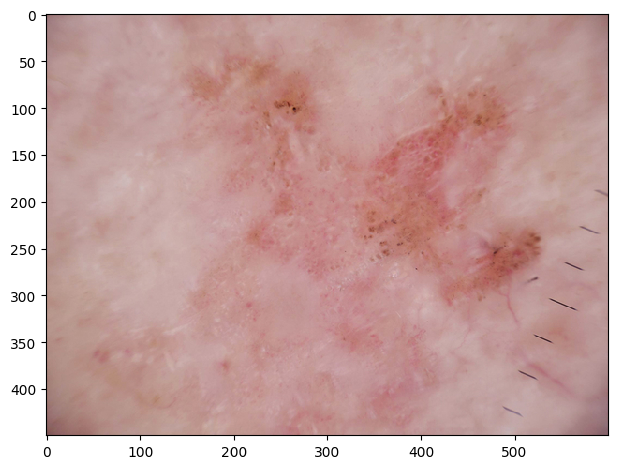

In [ ]:
from PIL import Image
import io
from skimage import io, transform, img_as_float


def merge(img_path, ques):
  I = io.imread(img_path)
  io.imshow(I)

  preds = vit_preds(img_path)
  txt_preds = predict_answer(ques)

  #print(preds)
  #print(ques, txt_preds, "\n")
  print(ques, "\n")

  report = {"name" : None,
            "cancerous" : None,
            "severity" : None,
            "cause" : None,
            "contagious" : None,
            }
  keys = list(report)

  for i in range(len(preds)):
    print(f"Report:{keys[i]}\nEncode lst:{encode_lst[keys[i]][preds[i]]}\n")
    report[keys[i]] = encode_lst[keys[i]][preds[i]]

  return report[predict_answer(ques)]


img_path = "/content/drive/MyDrive/Thesis/Skin Disease Dataset/training split/combined-img/ISIC_0024923.jpg"

ques = "What is the incubation period?"
print(f"Answer : (Attribute: {predict_answer(ques)})", merge(img_path, ques))

In [ ]:
import tensorflow as tf


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(vis_model)
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 86404628


In [ ]:
# text_model.summary()

In [ ]:
# questions = ["What type is the dog?",
#              "What is the colour?",
#              "What size is the dog?",
#              "What species of dog is it?",
#              "What colour is the dog?",
#              "Tell the size of the dog",
#              "What is the breed of this dog",
#              "Tell the colour of this dog",
#              "Determine the dog's size"]

# answers = ["Q1", "Q2", "Q3", "Q1", "Q2", "Q3", "Q1", "Q2", "Q3"]  # Labels

# # Encode answers as integers
# from sklearn.preprocessing import LabelEncoder
# label_encoder = LabelEncoder()
# labels = label_encoder.fit_transform(answers)


In [ ]:

# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# # from keras.preprocessing.text import Tokenizer
# # from keras.preprocessing.sequence import pad_sequences

# tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
# tokenizer.fit_on_texts(questions)
# sequences = tokenizer.texts_to_sequences(questions)
# padded_sequences = pad_sequences(sequences, maxlen=20, padding='post')


In [ ]:
# import tensorflow as tf

# model = tf.keras.Sequential([
#     tf.keras.layers.Embedding(input_dim=10000, output_dim=64, input_length=20),
#     tf.keras.layers.LSTM(64),
#     tf.keras.layers.Dense(32, activation='relu'),
#     tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
# ])

# model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model.fit(padded_sequences, labels, epochs=10, batch_size=16)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.0989
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3333 - loss: 1.0986
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3333 - loss: 1.0985
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3333 - loss: 1.0984
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3333 - loss: 1.0982
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3333 - loss: 1.0979
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3333 - loss: 1.0977
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3333 - loss: 1.0974
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3333 - loss: 1.0970
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3333 - loss: 1.0965


In [ ]:
# import torch
# import torch.nn as nn

# class LSTMQuestionAnswering(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=1):
#         super(LSTMQuestionAnswering, self).__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
#         self.fc = nn.Linear(hidden_dim, output_dim)

#     def forward(self, x):
#         x = self.embedding(x)              # (batch_size, seq_len, embed_dim)
#         output, (hidden, cell) = self.lstm(x)
#         out = self.fc(hidden[-1])           # (batch_size, output_dim)
#         return out


In [ ]:
# # Assume vocab size is 5000
# model = LSTMQuestionAnswering(vocab_size=5000, embed_dim=128, hidden_dim=256, output_dim=5000)

# # Dummy input: a batch of 2 questions, each 10 tokens long
# dummy_input = torch.randint(0, 5000, (2, 10))  # (batch_size=2, seq_len=10)

# # Forward pass
# output = model(dummy_input)  # (batch_size=2, output_dim=5000)

# # Get predicted word
# predicted_word_ids = torch.argmax(output, dim=1)
# print(predicted_word_ids)  # Predicted word indices


tensor([4180, 3534])


In [ ]:
# def predict_question(question):
#     seq = tokenizer.texts_to_sequences([question])
#     padded = pad_sequences(seq, maxlen=20, padding='post')
#     pred = model.predict(padded)
#     label_index = pred.argmax()
#     return label_encoder.inverse_transform([label_index])[0]

# print(predict_question("What kind of dog is it?"))

# print(predict_question("What is the colour of this dog?"))


AttributeError: 'LSTMQuestionAnswering' object has no attribute 'predict'

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from collections import Counter
# import numpy as np

# #=== Dummy Data ===
# questions = ["What type is the dog?",
#              "What is the colour?",
#              "What size is the dog?",
#              "What species of dog is it?",
#              "What colour is the dog?",
#              "Tell the size of the dog",
#              "What is the breed of this dog",
#              "Tell the colour of this dog",
#              "Determine the dog's size"]

# answers = ["Q1", "Q2", "Q3", "Q1", "Q2", "Q3", "Q1", "Q2", "Q3"]  # Labels

# # questions = [
# #     "Is the sky blue?",
# #     "Can pigs fly?",
# #     "Is water wet?",
# #     "Do humans need oxygen?",
# #     "Is fire cold?"
# # ]

# # answers = ["yes", "no", "yes", "yes", "no"]

# # === Preprocessing ===
# class Vocabulary:
#     def __init__(self, min_freq=1):
#         self.token2idx = {"<PAD>": 0, "<UNK>": 1}
#         self.idx2token = ["<PAD>", "<UNK>"]
#         self.min_freq = min_freq

#     def build_vocab(self, texts):
#         counter = Counter(token for text in texts for token in text.lower().split())
#         for word, freq in counter.items():
#             if freq >= self.min_freq:
#                 self.token2idx[word] = len(self.idx2token)
#                 self.idx2token.append(word)

#     def encode(self, text):
#         return [self.token2idx.get(token, 1) for token in text.lower().split()]

#     def pad_sequence(self, seq, max_len):
#         return seq + [0] * (max_len - len(seq))

# # === Encode Labels ===
# label_encoder = LabelEncoder()
# encoded_labels = label_encoder.fit_transform(answers)

# # === Create Dataset ===
# class QuestionDataset(Dataset):
#     def __init__(self, questions, labels, vocab, max_len):
#         self.data = []
#         for q, label in zip(questions, labels):
#             encoded = vocab.encode(q)
#             padded = vocab.pad_sequence(encoded, max_len)
#             self.data.append((torch.tensor(padded), torch.tensor(label)))

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         return self.data[idx]

# # === LSTM Model ===
# class LSTMClassifier(nn.Module):
#     def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embedding_dim)
#         self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
#         self.fc = nn.Linear(hidden_dim, output_dim)

#     def forward(self, x):
#         embedded = self.embedding(x)
#         _, (hidden, _) = self.lstm(embedded)
#         return self.fc(hidden.squeeze(0))

# # === Setup ===
# vocab = Vocabulary()
# vocab.build_vocab(questions)
# max_len = max(len(q.split()) for q in questions)

# dataset = QuestionDataset(questions, encoded_labels, vocab, max_len)
# train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

# model = LSTMClassifier(vocab_size=len(vocab.idx2token), embedding_dim=64, hidden_dim=128, output_dim=len(label_encoder.classes_))
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# # === Training Loop ===
# for epoch in range(10):
#     total_loss = 0
#     for x_batch, y_batch in train_loader:
#         optimizer.zero_grad()
#         outputs = model(x_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

# # === Inference ===
# def predict(question):
#     model.eval()
#     encoded = vocab.encode(question)
#     padded = vocab.pad_sequence(encoded, max_len)
#     input_tensor = torch.tensor(padded).unsqueeze(0)
#     with torch.no_grad():
#         output = model(input_tensor)
#         pred = torch.argmax(output, dim=1).item()
#         return label_encoder.inverse_transform([pred])[0]

# # === Test ===
# # print(predict("Can dogs fly?"))   # Expected: "no"
# # print(predict("Do fish swim?"))   # Expected: "yes"

# print(predict("What kind of dog is it?"))            # Expected: "Q1"
# print(predict("What is the colour of this dog?"))    # Expected: "Q2"

Epoch 1: Loss = 5.8829
Epoch 2: Loss = 5.3848
Epoch 3: Loss = 5.0584
Epoch 4: Loss = 4.8545
Epoch 5: Loss = 4.5438
Epoch 6: Loss = 4.2702
Epoch 7: Loss = 3.6919
Epoch 8: Loss = 2.8350
Epoch 9: Loss = 3.2572
Epoch 10: Loss = 1.7153
Q1
Q1
